# Laboratorio 03 - Clasificacion con regresion logistica

Implementando regresión logística (clasificacion) al dataset TELECOM CUSTOMER CHURN (Cell2Cell).
link del dataset: https://www.kaggle.com/datasets/jpacse/datasets-for-churn-telecom?select=cell2celltrain.csv

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Importar Librerias

In [3]:
# Manejo de rutas y directorios
import os

# Computación vectorial y científica
import numpy as np

# Librería para preprocesamiento del dataset
import pandas as pd

# Librerías para graficación
from matplotlib import pyplot
# Para habilitar la creacion de graficos tridimencionales con matplotlib
from mpl_toolkits.mplot3d import Axes3D

# Incrusta gráficas en el cuadernillo
%matplotlib inline


# 2. Carga del Dataset

Se carga el archivo cell2celltrain.csv desde nuestro Google Drive (este archivo es el Dataset)

In [ ]:
# Cargar el dataset desde Google Drive
ruta = '/content/drive/MyDrive/machine learning/datasets/cell2celltrain.csv'

data = pd.read_csv(ruta)

print(f'Dimensiones: {data.shape[0]} filas x {data.shape[1]} columnas')
print(f'm = {data.shape[0]} registros de clientes')
print(f'n = {data.shape[1]} características')
print()
data.head()

Dimensiones: 51047 filas x 58 columnas
m = 51047 registros de clientes
n = 58 características



,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


# 3. Procesamiento de los datos con Pandas

Antes de entrenar el modelo se debe realizar el procesamiento del Dataset
1. Revisión de tipos de datos
2. Identificación y manejo de valores nulos
3. Codificación de variables categóricas
4. Separación de variables X e y

## 3.1 Revision de Tipos de datos

In [6]:
print('=== TIPOS DE DATOS ===')
data.info()

=== TIPOS DE DATOS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls      

## 3.2 Verificacion de Valores Nulos
Se identifican las columnas con valores faltantes, los valores nulos en columnas numéricas se rellenan con la mediana de cada columna, y en columnas categóricas con la moda.

In [7]:
print('=== VALORES NULOS POR COLUMNA ===')
nulos = data.isnull().sum()
print(nulos[nulos > 0])
print(f'\nTotal de valores nulos: {data.isnull().sum().sum()}')

=== VALORES NULOS POR COLUMNA ===
MonthlyRevenue           156
MonthlyMinutes           156
TotalRecurringCharge     156
DirectorAssistedCalls    156
OverageMinutes           156
RoamingCalls             156
PercChangeMinutes        367
PercChangeRevenues       367
ServiceArea               24
Handsets                   1
HandsetModels              1
CurrentEquipmentDays       1
AgeHH1                   909
AgeHH2                   909
dtype: int64

Total de valores nulos: 3515


## 3.3 Codificacion de Variables Categoricas
Las columnas de tipo texto (object) no pueden ser procesadas directamente por el modelo. Se convierten a valores numéricos usando `pd.Categorical().codes`, que asigna un número entero a cada categoría única.

In [8]:
# Hacemos una copia para no modificar el original
df = data.copy()

# Identificando columnas numéricas y categóricas
cols_numericas   = df.select_dtypes(include=[np.number]).columns.tolist()
cols_categoricas = df.select_dtypes(include=['object']).columns.tolist()

print(f'Columnas numéricas:   {len(cols_numericas)}')
print(f'Columnas categóricas: {len(cols_categoricas)}')
print(f'Columnas categóricas: {cols_categoricas}')

Columnas numéricas:   35
Columnas categóricas: 23
Columnas categóricas: ['Churn', 'ServiceArea', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'NewCellphoneUser', 'NotNewCellphoneUser', 'OwnsMotorcycle', 'HandsetPrice', 'MadeCallToRetentionTeam', 'CreditRating', 'PrizmCode', 'Occupation', 'MaritalStatus']


In [9]:
# Rellenar nulos en columnas numéricas con la mediana
for col in cols_numericas:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())
        print(f'  Nulos en "{col}" rellenados con mediana')

# Codificar columnas categóricas y rellenar sus nulos con la moda
for col in cols_categoricas:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])
    df[col] = pd.Categorical(df[col]).codes
    print(f'  Columna "{col}" codificada a numérico')

print(f'Valores nulos restantes: {df.isnull().sum().sum()}')

  Nulos en "MonthlyRevenue" rellenados con mediana
  Nulos en "MonthlyMinutes" rellenados con mediana
  Nulos en "TotalRecurringCharge" rellenados con mediana
  Nulos en "DirectorAssistedCalls" rellenados con mediana
  Nulos en "OverageMinutes" rellenados con mediana
  Nulos en "RoamingCalls" rellenados con mediana
  Nulos en "PercChangeMinutes" rellenados con mediana
  Nulos en "PercChangeRevenues" rellenados con mediana
  Nulos en "Handsets" rellenados con mediana
  Nulos en "HandsetModels" rellenados con mediana
  Nulos en "CurrentEquipmentDays" rellenados con mediana
  Nulos en "AgeHH1" rellenados con mediana
  Nulos en "AgeHH2" rellenados con mediana
  Columna "Churn" codificada a numérico
  Columna "ServiceArea" codificada a numérico
  Columna "ChildrenInHH" codificada a numérico
  Columna "HandsetRefurbished" codificada a numérico
  Columna "HandsetWebCapable" codificada a numérico
  Columna "TruckOwner" codificada a numérico
  Columna "RVOwner" codificada a numérico
  Columna "

## 3.4 Separacion de Variables X e Y
Se separa la variable objetivo `Churn` del resto de características:
- **y:** columna `Churn` (0 = No cancela, 1 = Sí cancela)
- **X:** todas las demás columnas (características del cliente)

In [10]:
# Variable objetivo
y = df['Churn'].to_numpy(dtype=np.float64)

# Variables de entrada
X_cols = [col for col in df.columns if col != 'Churn']
X = df[X_cols].to_numpy(dtype=np.float64)

print(f'Forma de X: {X.shape}  →  {X.shape[0]} ejemplos, {X.shape[1]} características')
print(f'Forma de y: {y.shape}')
print(f'Distribución de Churn:')
print(f'  No cancela (0): {int(np.sum(y == 0))} clientes ({np.mean(y == 0)*100:.1f}%)')
print(f'  Sí cancela (1): {int(np.sum(y == 1))} clientes ({np.mean(y == 1)*100:.1f}%)')

Forma de X: (51047, 57)  →  51047 ejemplos, 57 características
Forma de y: (51047,)
Distribución de Churn:
  No cancela (0): 36336 clientes (71.2%)
  Sí cancela (1): 14711 clientes (28.8%)


## 3.5 Distribucion de la Variable Objetivo
Se grafica la distribución de la variable `Churn` para visualizar el balance entre las clases. ya que un dataset desbalanceado puede afectar el rendimiento del modelo.

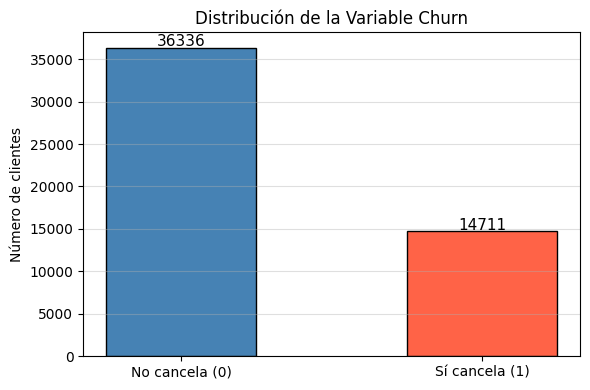

In [11]:
# Gráficacion de distribución de Churn
valores  = [int(np.sum(y == 0)), int(np.sum(y == 1))]
etiquetas = ['No cancela (0)', 'Sí cancela (1)']
colores   = ['steelblue', 'tomato']

pyplot.figure(figsize=(6, 4))
pyplot.bar(etiquetas, valores, color=colores, edgecolor='black', width=0.5)
for i, v in enumerate(valores):
    pyplot.text(i, v + 200, str(v), ha='center', fontsize=11)
pyplot.ylabel('Número de clientes')
pyplot.title('Distribución de la Variable Churn')
pyplot.grid(axis='y', alpha=0.4)
pyplot.tight_layout()
pyplot.show()

# 4. Division del Dataset: 80% Entrenamiento 20% Prueba
Dividiendo el dataset aleatoriamente usando numpy:
- **80% (X_train, y_train):** para entrenar el modelo y ajustar los parámetros θ
- **20% (X_test, y_test):** para evaluar el modelo con datos que nunca vio durante el entrenamiento


In [12]:
# División 80/20 con numpy
np.random.seed(42)
m_total = X.shape[0]
indices  = np.random.permutation(m_total)
corte    = int(m_total * 0.8)

idx_train = indices[:corte]
idx_test  = indices[corte:]

X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y[idx_train], y[idx_test]

m = y_train.size  # número de ejemplos de entrenamiento

print(f'Total de ejemplos:             {m_total}')
print(f'Ejemplos de entrenamiento (80%): {X_train.shape[0]}')
print(f'Ejemplos de prueba       (20%): {X_test.shape[0]}')

Total de ejemplos:             51047
Ejemplos de entrenamiento (80%): 40837
Ejemplos de prueba       (20%): 10210


# 5.Implementacion de la Regresion Logistica
La hipotesis para la regresión logistica se define como:

$$ h_\theta(x) = g(\theta^T x)$$

donde la función $g$ is la función sigmoidea. La función sigmoidea se define como:

$$g(z) = \frac{1}{1+e^{-z}}$$

La regresión logística es un modelo de clasificación binaria. A diferencia de la regresión lineal, la hipótesis pasa por la **función sigmoidea** que mapea cualquier valor real al rango (0, 1), interpretable como una probabilidad:


$$h_\theta(x) = g(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}$$

Si $h_\theta(x) \geq 0.5$ se predice clase 1 (cancela), de lo contrario clase 0 (no cancela).

## 5.1 Normalizacion de Caracteristicas
Las características tienen diferentes escalas (minutos de llamada, número de llamadas, edad y mas). La normalización asegura que el descenso por el gradiente converja correctamente. Se calcula la media y desviación estándar **solo con datos de entrenamiento** y se aplica la misma transformación a los datos de prueba.

In [13]:
def featureNormalize(X):
    """
    Normaliza las características de X (media=0, std=1).
    Retorna X normalizado, la media (mu) y desviación estándar (sigma).
    """
    X      = np.array(X, dtype=np.float64)
    mu     = np.mean(X, axis=0)
    sigma  = np.std(X, axis=0)
    sigma[sigma == 0] = 1  # evitar división por cero
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Normalizar con datos de entrenamiento
X_train_norm, mu, sigma = featureNormalize(X_train)

# Aplicar misma normalización a datos de prueba
X_test_norm = (X_test - mu) / sigma

print(f'Media (mu) primeras 5 cols:  {mu[:5].round(3)}')
print(f'Std (sigma) primeras 5 cols: {sigma[:5].round(3)}')

Media (mu) primeras 5 cols:  [3.20233672e+06 5.85560000e+01 5.21352000e+02 4.67410000e+01
 8.92000000e-01]
Std (sigma) primeras 5 cols: [1.16974183e+05 4.38690000e+01 5.23604000e+02 2.37720000e+01
 2.21900000e+00]


## 5.2 Agregar Termino de Intercepcion
Se agrega una columna de unos al inicio de X para representar el término de intercepción $\theta_0$, permitiendo escribir la hipótesis de forma vectorizada.

In [14]:
# Agregar columna de unos (término de intercepción theta_0)
X_train_ready = np.concatenate([np.ones((m, 1)), X_train_norm], axis=1)
X_test_ready  = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

m, n = X_train_ready.shape
print(f'X_train con intercepción: {X_train_ready.shape}')
print(f'X_test  con intercepción: {X_test_ready.shape}')

X_train con intercepción: (40837, 58)
X_test  con intercepción: (10210, 58)


## 5.3 Funcion Sigmoidea
La función sigmoidea es el núcleo de la **clasificación binaria** en la regresión logística. Transforma cualquier valor real en un número entre 0 y 1, interpretado como la **probabilidad de pertenecer a la clase positiva** (Churn = 1):

$$g(z) = \frac{1}{1 + e^{-z}}$$

Esto es lo que hace al modelo **binario**: la salida siempre es una probabilidad entre 0 y 1, y con un umbral de 0.5 se decide entre exactamente **dos clases**:
- $g(z) \geq 0.5$ → predice **Churn = 1** (cancela)
- $g(z) < 0.5$ → predice **Churn = 0** (no cancela)

In [15]:
def sigmoid(z):
    """
    Calcula la función sigmoidea de z.
    Mapea cualquier valor real al rango (0, 1).
    """
    z = np.array(z)
    g = 1 / (1 + np.exp(-z))
    return g

# Verificación de la función
print('Prueba de la función sigmoidea:')
z_prueba = [-100, -1, 0, 1, 100]
print(f'sigmoid({z_prueba}) = {sigmoid(z_prueba).round(4)}')
print(f'sigmoid(0) = {sigmoid(0)} (debe ser exactamente 0.5)')

Prueba de la función sigmoidea:
sigmoid([-100, -1, 0, 1, 100]) = [0.     0.2689 0.5    0.7311 1.    ]
sigmoid(0) = 0.5 (debe ser exactamente 0.5)


## 5.4 Funcion de Costo
La función de costo para regresión logística mide qué tan bien el modelo separa las dos clases. Se utiliza la **entropía cruzada binaria**:

$$J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log\left(h_\theta(x^{(i)})\right) - \left(1 - y^{(i)}\right) \log\left(1 - h_\theta(x^{(i)})\right) \right]$$

Un costo menor indica que el modelo clasifica mejor los ejemplos de entrenamiento.

In [16]:
def calcularCosto(theta, X, y):
    """
    Calcula el costo de la regresión logística usando entropía cruzada.
    """
    m = y.size
    h = sigmoid(X.dot(theta.T))
    h = np.clip(h, 1e-10, 1 - 1e-10)  # evitar log(0)
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    return J

# Verificar costo con theta = ceros
theta_prueba  = np.zeros(n)
costo_inicial = calcularCosto(theta_prueba, X_train_ready, y_train)
print(f'Costo inicial con theta = ceros: {costo_inicial:.4f}')
print('(Debe ser aproximadamente 0.6931 = ln(2))')

Costo inicial con theta = ceros: 0.6931
(Debe ser aproximadamente 0.6931 = ln(2))


## 5.5 Descenso por el Gradiente
El descenso por el gradiente actualiza iterativamente los parámetros θ para minimizar el costo. La regla de actualización es:

$$\theta_j := \theta_j - \frac{\alpha}{m} \sum_{i=1}^{m} \left(h_\theta(x^{(i)}) - y^{(i)}\right) x_j^{(i)}$$

Donde $\alpha$ es la **tasa de aprendizaje** que controla el tamaño de cada paso.

In [17]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    """
    Optimiza theta mediante descenso por gradiente.
    Retorna theta optimizado y el historial del costo.
    """
    m     = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h     = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(calcularCosto(theta, X, y))

    return theta, J_history

# 6. Entrenamiento del Modelo
Se entrena el modelo con una tasa de aprendizaje $\alpha = 0.1$ y 1,000 iteraciones sobre el conjunto de entrenamiento (80% de los datos). Se grafica la convergencia del costo para verificar que el algoritmo esté aprendiendo — el costo debe decrecer y estabilizarse.

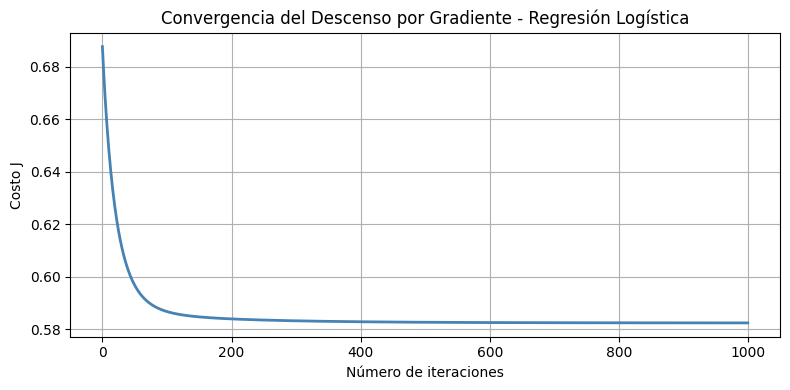

Costo inicial: 0.6876
Costo final:   0.5825
Theta calculado (primeros 5): [-0.9374 -0.1013  0.0739 -0.108  -0.0858]


In [18]:
# Parámetros de entrenamiento
alpha     = 0.1
num_iters = 1000

# Inicializar theta en ceros y entrenar
theta = np.zeros(n)
theta, J_history = descensoGradiente(theta, X_train_ready, y_train, alpha, num_iters)

# Gráfica de convergencia del costo
pyplot.figure(figsize=(8, 4))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='steelblue')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Descenso por Gradiente - Regresión Logística')
pyplot.grid(True)
pyplot.tight_layout()
pyplot.show()

print(f'Costo inicial: {J_history[0]:.4f}')
print(f'Costo final:   {J_history[-1]:.4f}')
print(f'Theta calculado (primeros 5): {theta[:5].round(4)}')

# 7. Funcion de Prediccion Binaria
Se implementa la función `predict` que completa el proceso de **clasificación binaria**:
1. Calcula $z = \theta^T x$
2. Aplica la sigmoidea: probabilidad = $g(z) \in (0, 1)$
3. Aplica el **umbral binario de 0.5** para decidir entre las dos clases:
   - Probabilidad $\geq$ 0.5 → **Clase 1** (cliente cancela)
   - Probabilidad $<$ 0.5 → **Clase 0** (cliente no cancela)

Este umbral es lo que convierte una probabilidad continua en una **decisión binaria**.

In [20]:
def predict(theta, X):
    """
    Predice la etiqueta (0 o 1) usando regresión logística.
    Umbral: sigmoid(theta.T * x) >= 0.5 → predice 1.
    """
    p = np.round(sigmoid(X.dot(theta.T)))
    return p

# 8. Evaluacion del Modelo
Se evalúa el modelo en ambos conjuntos para detectar posible sobreajuste (overfitting):
- **Entrenamiento:** mide qué tan bien aprendió con los datos de entrenamiento
- **Prueba (20%):** mide la capacidad de generalización con datos nunca vistos

In [21]:
# Precisión en entrenamiento y prueba
p_train = predict(theta, X_train_ready)
p_test  = predict(theta, X_test_ready)

acc_train = np.mean(p_train == y_train) * 100
acc_test  = np.mean(p_test  == y_test)  * 100

print('=== EVALUACIÓN DEL MODELO ===')
print(f'Precisión en entrenamiento (80%): {acc_train:.2f} %')
print(f'Precisión en prueba        (20%): {acc_test:.2f} %')

=== EVALUACIÓN DEL MODELO ===
Precisión en entrenamiento (80%): 71.19 %
Precisión en prueba        (20%): 71.25 %


## 8.1 Matriz de Confusion
La matriz de confusión muestra en detalle cómo clasifica el modelo:
- **TN (Verdaderos Negativos):** clientes que no cancelaron y el modelo predijo correctamente
- **FP (Falsos Positivos):** clientes que no cancelaron pero el modelo predijo que sí
- **FN (Falsos Negativos):** clientes que sí cancelaron pero el modelo predijo que no
- **TP (Verdaderos Positivos):** clientes que sí cancelaron y el modelo predijo correctamente

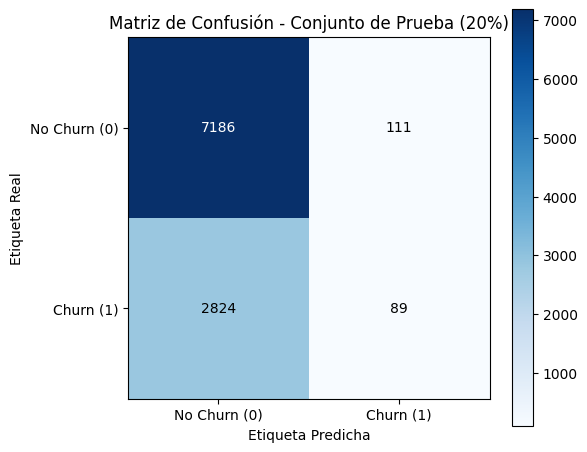

Verdaderos Negativos (TN): 7186
Falsos Positivos     (FP): 111
Falsos Negativos     (FN): 2824
Verdaderos Positivos (TP): 89


In [22]:
# Matriz de confusión implementada con numpy
TN = int(np.sum((p_test == 0) & (y_test == 0)))
FP = int(np.sum((p_test == 1) & (y_test == 0)))
FN = int(np.sum((p_test == 0) & (y_test == 1)))
TP = int(np.sum((p_test == 1) & (y_test == 1)))

cm = np.array([[TN, FP], [FN, TP]])

# Graficar matriz de confusión
fig, ax = pyplot.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=pyplot.cm.Blues)
pyplot.colorbar(im, ax=ax)

clases     = ['No Churn (0)', 'Churn (1)']
tick_marks = np.arange(2)
ax.set_xticks(tick_marks); ax.set_xticklabels(clases)
ax.set_yticks(tick_marks); ax.set_yticklabels(clases)

thresh = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')

pyplot.title('Matriz de Confusión - Conjunto de Prueba (20%)')
pyplot.ylabel('Etiqueta Real')
pyplot.xlabel('Etiqueta Predicha')
pyplot.tight_layout()
pyplot.show()

print(f'Verdaderos Negativos (TN): {TN}')
print(f'Falsos Positivos     (FP): {FP}')
print(f'Falsos Negativos     (FN): {FN}')
print(f'Verdaderos Positivos (TP): {TP}')

# 8.2 Metricas de Confusion
Se calculan métricas adicionales para evaluar el modelo con más detalle:
- **Precisión:** de los que se predijo como Churn, ¿cuántos realmente cancelaron?
- **Recall:** de los que realmente cancelaron, ¿cuántos detectó el modelo?
- **F1-Score:** media armónica entre precisión y recall

In [23]:
# Métricas calculadas con numpy
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print('=== MÉTRICAS DE CLASIFICACIÓN (Conjunto de Prueba) ===')
print(f'Accuracy  (Exactitud): {acc_test:.2f} %')
print(f'Precision:             {precision:.4f}')
print(f'Recall:                {recall:.4f}')
print(f'F1-Score:              {f1:.4f}')

=== MÉTRICAS DE CLASIFICACIÓN (Conjunto de Prueba) ===
Accuracy  (Exactitud): 71.25 %
Precision:             0.4450
Recall:                0.0306
F1-Score:              0.0572


# 9. Predicciones sobre el Conjunto de Prueba
Se muestra una tabla con los resultados de predicción para los primeros ejemplos del conjunto de prueba, mostrando la probabilidad calculada por el modelo, la predicción final y el valor real.

In [24]:
# Calcular probabilidades para todo el conjunto de prueba
probabilidades = sigmoid(X_test_ready.dot(theta))

# Crear tabla de resultados con Pandas
df_resultados = pd.DataFrame({
    'Probabilidad de Churn (%)': (probabilidades * 100).round(2),
    'Predicción (0=No cancela, 1=Cancela)': p_test.astype(int),
    'Valor Real': y_test.astype(int),
    'Correcto': (p_test == y_test).astype(int)
})

print(f'Total de ejemplos en prueba: {len(df_resultados)}')
print(f'Correctamente clasificados:  {df_resultados["Correcto"].sum()}')
print()
print('=== PRIMEROS 100 RESULTADOS ===')
df_resultados.head(100)

Total de ejemplos en prueba: 10210
Correctamente clasificados:  7275

=== PRIMEROS 100 RESULTADOS ===


,Probabilidad de Churn (%),"Predicción (0=No cancela, 1=Cancela)",Valor Real,Correcto
0,41.77,0,1,0
1,25.28,0,0,1
2,24.26,0,0,1
3,28.81,0,0,1
4,30.39,0,1,0
...,...,...,...,...
95,18.10,0,0,1
96,18.61,0,0,1
97,21.44,0,0,1
98,21.68,0,1,0


## 9.1 Grafica de Probabilidades Predichas
Se visualiza la distribución de probabilidades predichas para cada clase real, lo que permite ver qué tan bien el modelo separa a los clientes que cancelan de los que no.

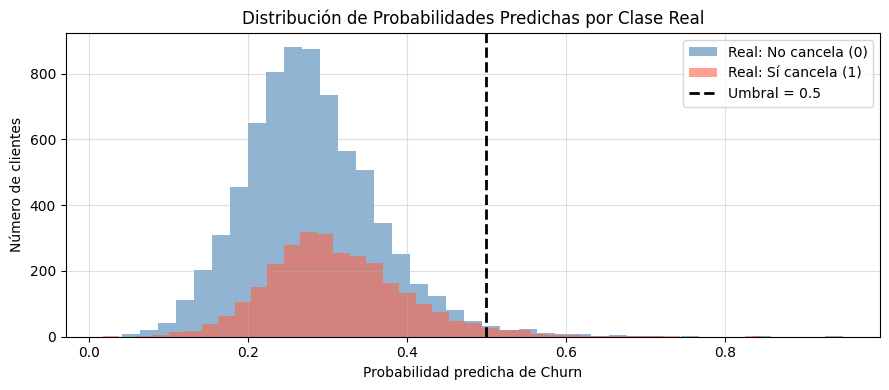

In [25]:
# Distribución de probabilidades predichas por clase real
prob_no_churn = probabilidades[y_test == 0]
prob_churn    = probabilidades[y_test == 1]

pyplot.figure(figsize=(9, 4))
pyplot.hist(prob_no_churn, bins=40, alpha=0.6, color='steelblue', label='Real: No cancela (0)')
pyplot.hist(prob_churn,    bins=40, alpha=0.6, color='tomato',    label='Real: Sí cancela (1)')
pyplot.axvline(x=0.5, color='black', linestyle='--', lw=2, label='Umbral = 0.5')
pyplot.xlabel('Probabilidad predicha de Churn')
pyplot.ylabel('Número de clientes')
pyplot.title('Distribución de Probabilidades Predichas por Clase Real')
pyplot.legend()
pyplot.grid(True, alpha=0.4)
pyplot.tight_layout()
pyplot.show()